<a href="https://colab.research.google.com/github/EstivenA/Practica4_Vision_computador_IA/blob/main/Reto2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports and drive

In [ ]:
# import the necessary packages
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Activation, Flatten, Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np
import cv2
from google.colab.patches import cv2_imshow
import os
import random
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# Read images and create dataset

Dataset available on: https://www.kaggle.com/datasets/apollo2506/landuse-scene-classification

In [ ]:
base_path = '/content/drive/MyDrive/'
folder = 'landuse/'
subfolders = ['harbor', 'denseresidential', 'airplane']

data = []
labels = []

### Sequential

In [ ]:
for subfolder in subfolders:
  print('Subfolder loading: ', subfolder)
  files = [f for f in os.listdir(base_path + folder + subfolder) if f.endswith('.png')]
  for file in files:
    img = cv2.imread(base_path + folder + subfolder + '/' + file, cv2.IMREAD_COLOR)
    img = img.astype('float32') / 255.0
    img = cv2.resize(img, (128, 128))
    data.append(img)
    labels.append(subfolder)

Subfolder loading:  harbor
Subfolder loading:  denseresidential
Subfolder loading:  airplane


### Non sequential

In [ ]:
for subfolder in subfolders:
    print('Subfolder loading: ', subfolder)
    files = [f for f in os.listdir(base_path + folder + subfolder) if f.endswith('.png')]
    for file in files:
        img = cv2.imread(base_path + folder + subfolder + '/' + file)
        if img is not None:
            img = cv2.resize(img, (224, 224))
            data.append(img)
            labels.append(subfolder)

data = np.array(data, dtype="float32")
data = preprocess_input(data)

Subfolder loading:  harbor
Subfolder loading:  denseresidential
Subfolder loading:  airplane


In [ ]:
# encode the labels, converting them from strings to integers
lb = LabelBinarizer()
labels = lb.fit_transform(labels)

# Split dataset into train and test

In [ ]:
# perform a training and testing split, using 75% of the data for
# training and 25% for evaluation
(trainX, testX, trainY, testY) = train_test_split(np.array(data), np.array(labels), test_size=0.25, random_state=42)

# Define model architecture

### Sequential

In [ ]:
# define our Convolutional Neural Network architecture
model = Sequential()
model.add(Conv2D(16, (3, 3), padding="same", input_shape=(128, 128, 3)))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
model.add(Conv2D(32, (3, 3), padding="same"))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
model.add(Conv2D(64, (3, 3), padding="same"))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
model.add(Conv2D(128, (3, 3), padding="same"))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
model.add(Conv2D(256, (3, 3), padding="same"))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
model.add(Flatten())
model.add(Dense(3))
model.add(Activation("softmax"))

#Summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │        12,291 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 3)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 404,899 (1.54 MB)

 Trainable params: 404,899 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

### Non sequential

In [ ]:
input_tensor = Input(shape=(224, 224, 3))

base_model = ResNet50(weights="imagenet", include_top=False, input_tensor=input_tensor)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x) # Evita el sobreajuste
outputs = Dense(len(subfolders), activation="softmax")(x)

model_non_sequential = Model(inputs=base_model.input, outputs=outputs)

model_non_sequential.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_42"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,027 (91.98 MB)

 Trainable params: 525,315 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

# Compile model and train

### Sequential

In [ ]:
opt = Adam(learning_rate=1e-3, decay=1e-3 / 50)
model.compile(loss="categorical_crossentropy", optimizer=opt, metrics=["accuracy"])
H = model.fit(trainX, trainY, validation_data=(testX, testY),	epochs=15, batch_size=32)

/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Epoch 1/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.4987 - loss: 0.9580 - val_accuracy: 0.6960 - val_loss: 0.6512
Epoch 2/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 32s 884ms/step - accuracy: 0.7289 - loss: 0.6438 - val_accuracy: 0.8027 - val_loss: 0.4772
Epoch 3/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 32s 894ms/step - accuracy: 0.8142 - loss: 0.4732 - val_accuracy: 0.8853 - val_loss: 0.3102
Epoch 4/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 41s 905ms/step - accuracy: 0.9049 - loss: 0.2816 - val_accuracy: 0.9413 - val_loss: 0.1780
Epoch 5/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 32s 887ms/step - accuracy: 0.9289 - loss: 0.2097 - val_accuracy: 0.9520 - val_loss: 0.1631
Epoch 6/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 32s 897ms/step - accuracy: 0.9093 - loss: 0.2403 - val_accuracy: 0.8933 - val_loss: 0.3076
Epoch 7/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 42s 913ms/step - accuracy: 0.9431 - loss: 0.1685 - val_accuracy: 0.9547 - val_loss: 0.1557
Epoch 8/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 39s 882ms/step - accuracy: 0.9751 - loss: 0.0813 - val_accurac

### Non sequential

In [ ]:
opt = Adam(learning_rate=1e-4)
model_non_sequential.compile(loss="categorical_crossentropy", optimizer=opt, metrics=["accuracy"])
H = model_non_sequential.fit(
    trainX, trainY,
    validation_data=(testX, testY),
    epochs=15,
    batch_size=32
)

Epoch 1/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 308s 8s/step - accuracy: 0.7573 - loss: 0.6356 - val_accuracy: 0.9840 - val_loss: 0.0922
Epoch 2/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 322s 8s/step - accuracy: 0.9671 - loss: 0.1082 - val_accuracy: 0.9920 - val_loss: 0.0435
Epoch 3/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 304s 8s/step - accuracy: 0.9858 - loss: 0.0589 - val_accuracy: 0.9947 - val_loss: 0.0300
Epoch 4/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 291s 8s/step - accuracy: 0.9876 - loss: 0.0417 - val_accuracy: 0.9973 - val_loss: 0.0245
Epoch 5/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 281s 8s/step - accuracy: 0.9964 - loss: 0.0203 - val_accuracy: 0.9973 - val_loss: 0.0193
Epoch 6/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 278s 8s/step - accuracy: 0.9982 - loss: 0.0177 - val_accuracy: 0.9973 - val_loss: 0.0170
Epoch 7/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 322s 8s/step - accuracy: 0.9973 - loss: 0.0173 - val_accuracy: 0.9973 - val_loss: 0.0145
Epoch 8/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 322s 8s/step - accuracy: 0.9982 - loss: 0.0130 - val_accuracy: 0.9973 - v

# Evaluate model

### Sequential

In [ ]:
predictions = model.predict(testX, batch_size=32)
print(classification_report(testY.argmax(axis=1),	predictions.argmax(axis=1), target_names=lb.classes_))

12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 430ms/step
                  precision    recall  f1-score   support

        airplane       0.99      0.96      0.98       135
denseresidential       0.96      1.00      0.98       115
          harbor       0.98      0.97      0.97       125

        accuracy                           0.98       375
       macro avg       0.98      0.98      0.98       375
    weighted avg       0.98      0.98      0.98       375



### Non sequential

In [ ]:
predictions = model_non_sequential.predict(testX, batch_size=32)
print(classification_report(
    testY.argmax(axis=1),
    predictions.argmax(axis=1),
    target_names=lb.classes_
))

12/12 ━━━━━━━━━━━━━━━━━━━━ 76s 6s/step
                  precision    recall  f1-score   support

        airplane       1.00      0.99      1.00       135
denseresidential       0.99      1.00      1.00       115
          harbor       1.00      1.00      1.00       125

        accuracy                           1.00       375
       macro avg       1.00      1.00      1.00       375
    weighted avg       1.00      1.00      1.00       375



In [ ]:
print(lb.classes_)

['airplane' 'denseresidential' 'harbor']


# Test on random sample

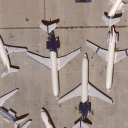

Ground truth class:  airplane
Predicted class:  airplane


In [ ]:
rand_pos = random.randint(0, len(testX))
rand_img = testX[rand_pos]

#sequential
rand_img_resized = 255 * cv2.resize(rand_img, (128, 128))
cv2_imshow(rand_img_resized)

#Non sequential
#cv2_imshow(cv2.resize(rand_img, (224, 224)))

print('Ground truth class: ', lb.classes_[np.argmax(testY[rand_pos])])
print('Predicted class: ', lb.classes_[np.argmax(predictions[rand_pos])])

# Matriz de confusión

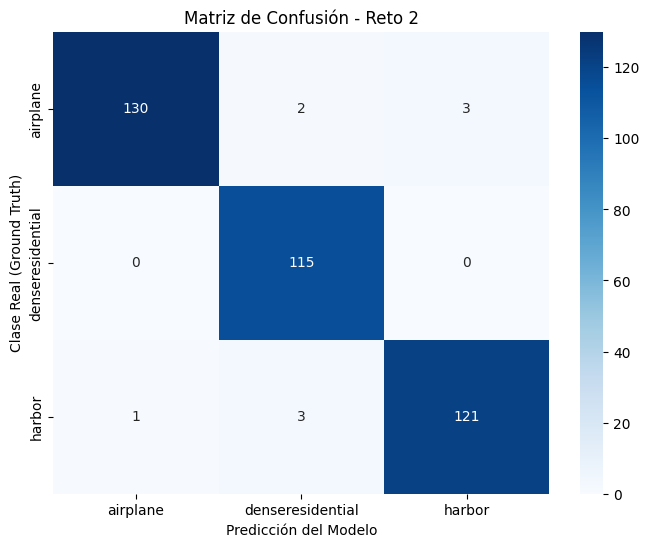

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(testY.argmax(axis=1), predictions.argmax(axis=1))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
            xticklabels=lb.classes_, yticklabels=lb.classes_)
plt.title("Matriz de Confusión - Reto 2")
plt.xlabel("Predicción del Modelo")
plt.ylabel("Clase Real (Ground Truth)")
plt.show()

# Conclusiones

- Al ver que nuestra red neuronal actual es delgada decidimos aumentar el numero de filtros, y luego duplicarlos en cada etapa profunda, asi la red tendrá más memoria y capacidad para extraer características más detalladas de las escenas. El primer filtro inicia en 16 y se va duplicando sucesivamente 4 veces hasta llegar a 256, como resultado obtuvimos que el accuracy aumentó de 89% a 98%, airplane pasó de 87% a 98%, denseresidential de 84% a 98% y harbor que pasó de 96% a 97%.
- Intentamos mejorar los resultados obtenidos con el modelo secuencial utilizando el modelo no secuencial ResNet50, para esto cambiamos el tamaño de las imagenes a 224x224 (la resolución nativa de ResNet) para que funcione mucho mejor ya que si se cambian o modifican los hiperparametros de resolucion de entrada se debería optimizar la extracción de caracteristicas. Logramos pasar del 90% al 100% de accuracy, esto gracias al transfer learning, que permite al modelo solo concentrarse en aprender las diferencias entre las imagenes y no tener que aprender a diferenciar desde cero colores, formas o figuras. Por último, gracias a que esta red utiliza 'atajos' para la información, no se confunde ni se le olvida detalles importantes, lo que permite que clasifique todas las imágenes de prueba sin cometer ni un solo error.
- ResNet fue entrenada originalmente usando Caffe, que lee las imágenes en formato BGR (Azul-Verde-Rojo) en lugar del estándar RGB. Por este motivo los valores de los píxeles se desplazan un poco, haciendo que los colores que vemos en pantalla no coincidan con la realidad, aunque para la IA sean perfectos para procesar.